# Data briefing - Exhibit 2: Futures market

**File:** `futures_prices.csv` (2024 Base/Peak snapshot, quote date 2023-09-29).

**Task (Data Description, section 3).** Plot Base and Peak prices by delivery period together with
`market_activity`. Identify:
- a suitable `market_activity` criterion and explain the choice;
- the products that appear usable;
- the products that appear illiquid;
- the non-overlapping ways of covering 2024 (CAL, Q1-Q4, or M01-M03 followed by Q2-Q4);
- any visible seasonal pattern in the futures prices.

Conclude which products the desk could use for a **coarse** and a **more granular** hedge, and
explain why overlapping annual + quarterly + monthly full-volume positions would not be an
appropriate comparison.

*All reported numbers are rounded to two decimal places.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../../data"

fut = pd.read_csv(f"{DATA}/futures_prices.csv",
                  parse_dates=["delivery_start", "delivery_end_exclusive"])

ORDER = ["CAL", "Q1", "Q2", "Q3", "Q4"] + [f"M{i:02d}" for i in range(1, 13)]
fut["delivery_period"] = pd.Categorical(fut["delivery_period"], categories=ORDER, ordered=True)
fut = fut.sort_values(["delivery_period", "load_type"]).reset_index(drop=True)

print("contracts:", len(fut), "|", fut["product_type"].value_counts().to_dict())
fut[["load_type", "product_type", "delivery_period",
     "delivery_start", "delivery_end_exclusive", "price_eur_mwh", "market_activity"]]

contracts: 34 | {'MONTH': 24, 'QUARTER': 8, 'YEAR': 2}


,load_type,product_type,delivery_period,delivery_start,delivery_end_exclusive,price_eur_mwh,market_activity
0,BASE,YEAR,CAL,2024-01-01,2025-01-01,77.26,5000
1,PEAK,YEAR,CAL,2024-01-01,2025-01-01,86.60,1400
2,BASE,QUARTER,Q1,2024-01-01,2024-04-01,66.42,3000
3,PEAK,QUARTER,Q1,2024-01-01,2024-04-01,77.70,840
4,BASE,QUARTER,Q2,2024-04-01,2024-07-01,66.23,2200
5,PEAK,QUARTER,Q2,2024-04-01,2024-07-01,64.76,616
6,BASE,QUARTER,Q3,2024-07-01,2024-10-01,74.74,1600
7,PEAK,QUARTER,Q3,2024-07-01,2024-10-01,69.07,448
8,BASE,QUARTER,Q4,2024-10-01,2025-01-01,101.39,1400
9,PEAK,QUARTER,Q4,2024-10-01,2025-01-01,134.42,392


## 1. Plot - Base/Peak price and market_activity by delivery period

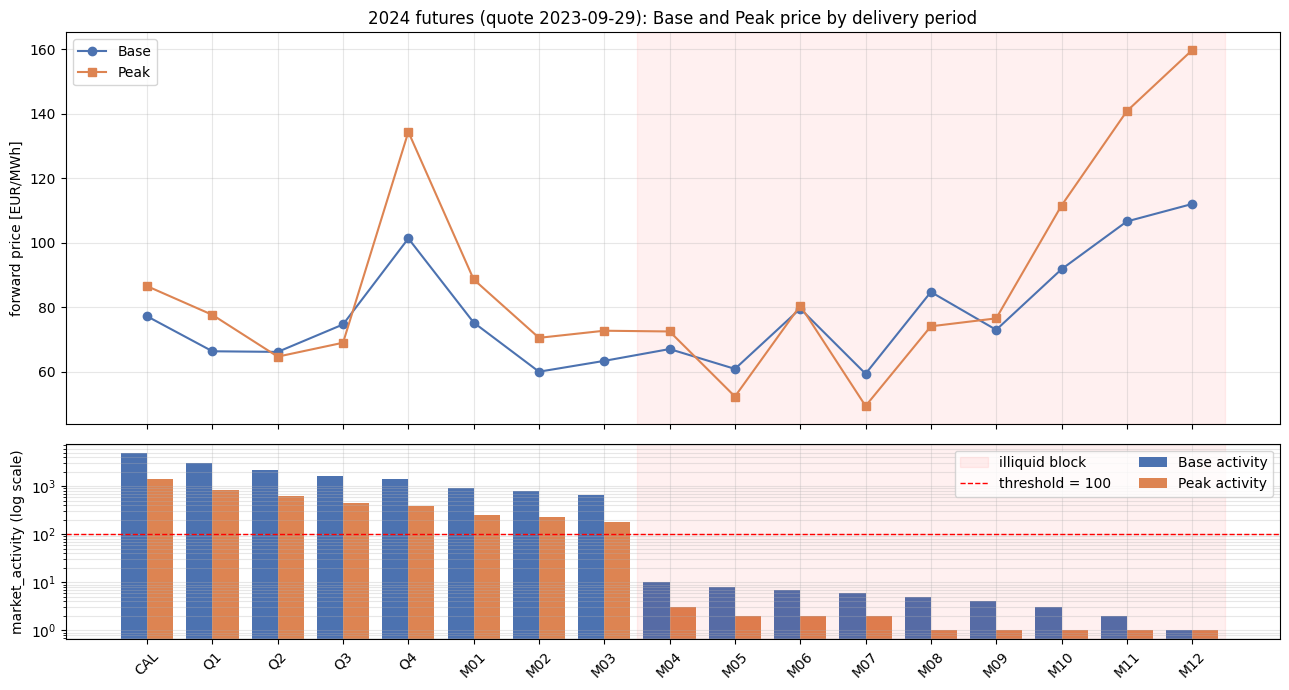

In [2]:
MIN_ACTIVITY = 100          # tradability threshold (justified in section 2)
fut["tradable"] = fut["market_activity"] >= MIN_ACTIVITY

base = fut[fut.load_type == "BASE"].set_index("delivery_period").reindex(ORDER)
peak = fut[fut.load_type == "PEAK"].set_index("delivery_period").reindex(ORDER)
x = np.arange(len(ORDER))
illiq_from = ORDER.index("M04") - 0.5    # M04..M12 are the illiquid block

fig, (axp, axa) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

axp.plot(x, base["price_eur_mwh"], "o-", color="#4C72B0", label="Base")
axp.plot(x, peak["price_eur_mwh"], "s-", color="#DD8452", label="Peak")
axp.axvspan(illiq_from, len(ORDER) - 0.5, color="red", alpha=0.06)
axp.set_ylabel("forward price [EUR/MWh]")
axp.set_title("2024 futures (quote 2023-09-29): Base and Peak price by delivery period")
axp.legend(); axp.grid(alpha=0.3)

w = 0.4
axa.bar(x - w/2, base["market_activity"], w, color="#4C72B0", label="Base activity")
axa.bar(x + w/2, peak["market_activity"], w, color="#DD8452", label="Peak activity")
axa.axvspan(illiq_from, len(ORDER) - 0.5, color="red", alpha=0.06, label="illiquid block")
axa.axhline(MIN_ACTIVITY, color="red", ls="--", lw=1, label=f"threshold = {MIN_ACTIVITY}")
axa.set_yscale("log")
axa.set_ylabel("market_activity (log scale)")
axa.set_xticks(x); axa.set_xticklabels(ORDER, rotation=45)
axa.legend(ncol=2); axa.grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

## 2. `market_activity` criterion

`market_activity` is a synthetic tradability score (higher = more actively traded). It is used
only to decide which products the desk could realistically transact on 29 September 2023.

**Criterion chosen: a product is tradable if `market_activity` >= 100.**

Reasons:

1. **A natural two-order-of-magnitude gap.** Sorting all 34 contracts by activity, the values fall
   into two clusters with nothing in between: M04-M12 (Base and Peak) all sit at **<= 10**, while
   every CAL, quarter and M01-M03 contract sits at **>= 182**. Any threshold in the open interval
   (10, 182) produces the *same* split - the choice is not sensitive to the exact number.
2. **Cross-check with a relative rule.** Requiring at least ~5 % of the activity of the same
   load-type CAL product (Base: 5 % of 5000 = 250; Peak: 5 % of 1400 = 70) gives the identical set.
3. It matches the hint in the task ("M01-M03 followed by Q2-Q4"): exactly the front three months
   are liquid enough to trade individually.

In [3]:
# show the gap and the sensitivity of the split
s = fut.sort_values("market_activity")[["load_type", "delivery_period", "market_activity"]]
print("lowest 6 :", list(s.head(6).itertuples(index=False, name=None)))
print("highest into the liquid cluster:",
      list(s[s.market_activity >= 100].sort_values("market_activity").head(4)
             .itertuples(index=False, name=None)))
print("gap: from", int(s[s.market_activity <= 10].market_activity.max()),
      "to", int(s[s.market_activity >= 100].market_activity.min()))

for thr in [25, 50, 100, 150, 180]:
    n = (fut["market_activity"] >= thr).sum()
    print(f"threshold {thr:>3}: {n} contracts tradable")

# cross-check: relative rule = at least 5% of the same-load-type CAL activity
for lt in ["BASE", "PEAK"]:
    sub = fut[fut.load_type == lt]
    cal = sub.loc[sub.delivery_period == "CAL", "market_activity"].iloc[0]
    keep = sorted(sub.loc[sub.market_activity >= 0.05 * cal, "delivery_period"].astype(str),
                  key=ORDER.index)
    print(f"{lt}: >= 5% of CAL ({0.05*cal:.0f}) ->", keep)


lowest 6 : [('PEAK', 'M08', 1), ('PEAK', 'M09', 1), ('PEAK', 'M11', 1), ('PEAK', 'M10', 1), ('PEAK', 'M12', 1), ('BASE', 'M12', 1)]
highest into the liquid cluster: [('PEAK', 'M03', 182), ('PEAK', 'M02', 224), ('PEAK', 'M01', 252), ('PEAK', 'Q4', 392)]
gap: from 10 to 182
threshold  25: 16 contracts tradable
threshold  50: 16 contracts tradable
threshold 100: 16 contracts tradable
threshold 150: 16 contracts tradable
threshold 180: 16 contracts tradable
BASE: >= 5% of CAL (250) -> ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 'M01', 'M02', 'M03']
PEAK: >= 5% of CAL (70) -> ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 'M01', 'M02', 'M03']


## 3. Usable vs. illiquid products

In [4]:
usable   = fut[fut.tradable]
illiquid = fut[~fut.tradable]

def periods(df, lt):
    return sorted(df[df.load_type == lt].delivery_period.astype(str).unique(),
                  key=ORDER.index)

print("USABLE  (market_activity >= 100)")
print("  Base:", periods(usable, "BASE"))
print("  Peak:", periods(usable, "PEAK"))
print(f"  -> {len(usable)} contracts: CAL, Q1-Q4, M01-M03 (each Base + Peak)")
print()
print("ILLIQUID (market_activity <= 10)")
print("  Base:", periods(illiquid, "BASE"))
print("  Peak:", periods(illiquid, "PEAK"))
print(f"  -> {len(illiquid)} contracts: M04-M12 (each Base + Peak)")

usable[["load_type", "delivery_period", "price_eur_mwh", "market_activity"]]

USABLE  (market_activity >= 100)
  Base: ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 'M01', 'M02', 'M03']
  Peak: ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 'M01', 'M02', 'M03']
  -> 16 contracts: CAL, Q1-Q4, M01-M03 (each Base + Peak)

ILLIQUID (market_activity <= 10)
  Base: ['M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']
  Peak: ['M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']
  -> 18 contracts: M04-M12 (each Base + Peak)


,load_type,delivery_period,price_eur_mwh,market_activity
0,BASE,CAL,77.26,5000
1,PEAK,CAL,86.60,1400
2,BASE,Q1,66.42,3000
3,PEAK,Q1,77.70,840
4,BASE,Q2,66.23,2200
5,PEAK,Q2,64.76,616
6,BASE,Q3,74.74,1600
7,PEAK,Q3,69.07,448
8,BASE,Q4,101.39,1400
9,PEAK,Q4,134.42,392


## 4. Non-overlapping ways of covering delivery year 2024

A hedge must tile the whole year with delivery periods that do not overlap. Using only tradable
products there are three such tilings:

| Tiling | Periods | Note |
|---|---|---|
| **CAL only** | CAL | one annual block - the *coarse* option |
| **Quarters** | Q1 + Q2 + Q3 + Q4 | four blocks |
| **Months + Quarters** | M01 + M02 + M03 + Q2 + Q3 + Q4 | finest tradable tiling - the *granular* option |

The granular tiling replaces Q1 by its three months (M01-M03 are liquid) but keeps Q2-Q4 as
quarters (their months M04-M12 are illiquid).

CAL only           covers 2024 exactly once, no overlap: True   gaps=[] overlaps=[]
Quarters           covers 2024 exactly once, no overlap: True   gaps=[] overlaps=[]
Months + Quarters  covers 2024 exactly once, no overlap: True   gaps=[] overlaps=[]


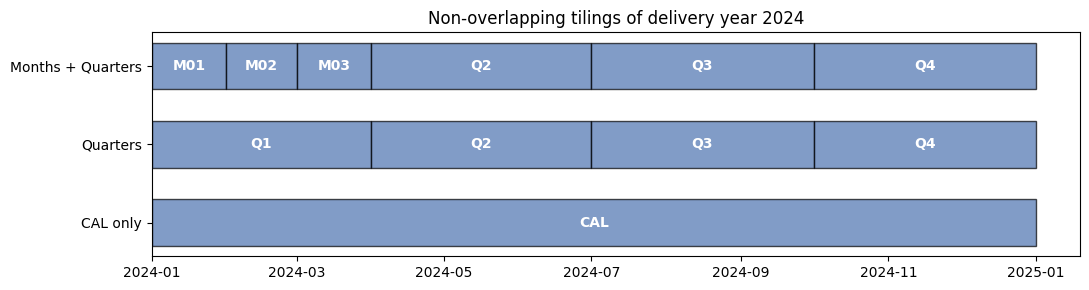

In [5]:
per = (fut.drop_duplicates("delivery_period")
          .set_index("delivery_period")[["delivery_start", "delivery_end_exclusive"]]
          .rename(columns={"delivery_start": "start", "delivery_end_exclusive": "end"}))

YEAR_START, YEAR_END = pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-01")

def check_cover(names):
    r = per.loc[names].sort_values("start")
    gaps      = [(a, b) for a, b in zip(r.end[:-1], r.start[1:]) if b > a]
    overlaps  = [(b, a) for a, b in zip(r.end[:-1], r.start[1:]) if b < a]
    full = (r.start.iloc[0] == YEAR_START) and (r.end.iloc[-1] == YEAR_END)
    return full and not gaps and not overlaps, gaps, overlaps

tilings = {
    "CAL only":          ["CAL"],
    "Quarters":          ["Q1", "Q2", "Q3", "Q4"],
    "Months + Quarters": ["M01", "M02", "M03", "Q2", "Q3", "Q4"],
}
for name, names in tilings.items():
    ok, gaps, ov = check_cover(names)
    print(f"{name:18s} covers 2024 exactly once, no overlap: {ok}   gaps={gaps} overlaps={ov}")

# Gantt view
fig, ax = plt.subplots(figsize=(11, 3))
for i, (name, names) in enumerate(tilings.items()):
    for p in names:
        s, e = mdates.date2num(per.loc[p, "start"]), mdates.date2num(per.loc[p, "end"])
        ax.barh(i, e - s, left=s, height=0.6, edgecolor="black", color="#4C72B0", alpha=0.7)
        ax.text((s + e) / 2, i, p, ha="center", va="center", color="white", fontweight="bold")
ax.set_yticks(range(len(tilings))); ax.set_yticklabels(list(tilings))
ax.xaxis_date(); ax.set_title("Non-overlapping tilings of delivery year 2024")
plt.tight_layout(); plt.show()

## 5. Seasonal pattern in the futures prices

Quarterly prices [EUR/MWh]
load_type         BASE   PEAK  Peak - Base
delivery_period                           
Q1               66.42  77.70        11.28
Q2               66.23  64.76        -1.47
Q3               74.74  69.07        -5.67
Q4              101.39 134.42        33.03


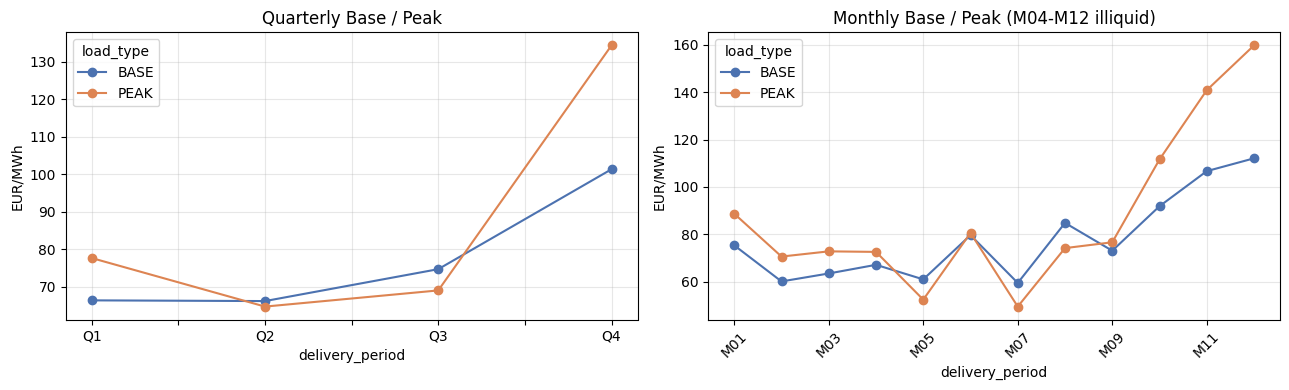


CAL: Base 77.26, Peak 86.60  (annual peak premium +9.34)
Cheapest month (Base): M07 59.45 | most expensive: M12 112.07


In [6]:
qp = (fut[fut.delivery_period.isin(["Q1", "Q2", "Q3", "Q4"])]
        .pivot_table(index="delivery_period", columns="load_type", values="price_eur_mwh", observed=True))
qp["Peak - Base"] = qp["PEAK"] - qp["BASE"]
print("Quarterly prices [EUR/MWh]")
print(qp.round(2))

mp = (fut[fut.product_type == "MONTH"]
        .pivot_table(index="delivery_period", columns="load_type", values="price_eur_mwh", observed=True))
mp["Peak - Base"] = mp["PEAK"] - mp["BASE"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
qp[["BASE", "PEAK"]].plot(marker="o", ax=a1, color=["#4C72B0", "#DD8452"])
a1.set_title("Quarterly Base / Peak"); a1.set_ylabel("EUR/MWh"); a1.grid(alpha=0.3)
mp[["BASE", "PEAK"]].plot(marker="o", ax=a2, color=["#4C72B0", "#DD8452"])
a2.set_title("Monthly Base / Peak (M04-M12 illiquid)"); a2.set_ylabel("EUR/MWh")
a2.tick_params(axis="x", rotation=45); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nCAL: Base 77.26, Peak 86.60  (annual peak premium +9.34)")
print("Cheapest month (Base):", mp["BASE"].idxmin(), round(mp["BASE"].min(), 2),
      "| most expensive:", mp["BASE"].idxmax(), round(mp["BASE"].max(), 2))

**What the prices show**

- **Level / winter premium.** Base rises from ~66 EUR/MWh in Q1-Q2 to 74.74 in Q3 and **101.39 in
  Q4**. Monthly Base is lowest in July (59.45; among tradable months February at 60.09) and highest in
  December (112.07). The forward curve prices a pronounced cold-season premium.
- **Peak-vs-Base spread flips with the season.** Positive in winter (Q1 **+11.28**, Q4 **+33.03**;
  Dec Peak 159.75) - high evening demand, little solar. Negative in summer (Q2 **-1.47**,
  Q3 **-5.67**; Jul Peak 49.47 < Base 59.45) - midday solar pushes the 08-20 window *below* the
  24 h average. This is the same shape the historical factors in Exhibit 3 describe, now visible in
  traded prices.

In [7]:
# consistency check: a coarser quote must equal the volume-weighted average of the finer ones
grid = (pd.to_datetime(pd.read_csv(f"{DATA}/slp_profiles.csv")["timestamp_utc"], utc=True)
          .dt.tz_convert("Europe/Berlin").dt.tz_localize(None))
is_peak_qh = (grid.dt.weekday < 5) & (grid.dt.hour >= 8) & (grid.dt.hour < 20)   # Mon-Fri 08-20

def _count(p, peak_only):
    m = (grid >= per.loc[p, "start"]) & (grid < per.loc[p, "end"])
    return int((m & is_peak_qh).sum() if peak_only else m.sum())

per["N_all"]  = [_count(p, False) for p in per.index]
per["N_peak"] = [_count(p, True)  for p in per.index]

def wavg(names, load_type, weightcol):
    sub = fut[(fut.load_type == load_type) & (fut.delivery_period.isin(names))]
    sub = sub.set_index("delivery_period").loc[names]
    return np.average(sub["price_eur_mwh"], weights=per.loc[names, weightcol])

Q, M = ["Q1", "Q2", "Q3", "Q4"], ["M01", "M02", "M03"]
print("quarter-hours per period (all):", per["N_all"].to_dict())
print(f"CAL Base 77.26  vs  Q1-Q4  N_all-weighted  {wavg(Q, 'BASE', 'N_all'):.2f}")
print(f"CAL Peak 86.60  vs  Q1-Q4  N_peak-weighted {wavg(Q, 'PEAK', 'N_peak'):.2f}")
print(f"Q1  Base 66.42  vs  M01-M03 N_all-weighted  {wavg(M, 'BASE', 'N_all'):.2f}")
print(f"Q1  Peak 77.70  vs  M01-M03 N_peak-weighted {wavg(M, 'PEAK', 'N_peak'):.2f}")

quarter-hours per period (all): {'CAL': 35136, 'Q1': 8732, 'Q2': 8736, 'Q3': 8832, 'Q4': 8836, 'M01': 2976, 'M02': 2784, 'M03': 2972, 'M04': 2880, 'M05': 2976, 'M06': 2880, 'M07': 2976, 'M08': 2976, 'M09': 2880, 'M10': 2980, 'M11': 2880, 'M12': 2976}
CAL Base 77.26  vs  Q1-Q4  N_all-weighted  77.26
CAL Peak 86.60  vs  Q1-Q4  N_peak-weighted 86.60
Q1  Base 66.42  vs  M01-M03 N_all-weighted  66.42
Q1  Peak 77.70  vs  M01-M03 N_peak-weighted 77.70


## 6. Conclusion - coarse vs. granular hedge

| Strategy | Products (Base + Peak each) | Rationale |
|---|---|---|
| **COARSE_CAL** | **CAL** | the two most liquid contracts (activity 5000 / 1400); one annual block |
| **GRANULAR** | **M01, M02, M03, Q2, Q3, Q4** | finest tiling using only tradable products; follows the seasonal shape far better |

**Why overlapping full-volume positions are not an appropriate comparison.** A hedge must cover the
delivery year *once*. Holding CAL **and** Q1-Q4 **and** M01-M03 simultaneously, each at the
portfolio's full volume, would buy every quarter-hour in Q1 three times (CAL + Q1 + the month) and
every quarter-hour in Q2-Q4 twice (CAL + quarter). That is a leveraged long position on power -
roughly 2-3x the customer load - not a hedge. The value-neutrality constraint in Stage 3 would then
be applied to multiply-counted energy, and COARSE_CAL vs. GRANULAR would carry completely different
total hedge volumes, so their realised cost and risk would not be comparable. A meaningful
comparison requires each strategy to tile 2024 exactly once with non-overlapping delivery periods
and then normalise both to the same market value.

In [8]:
coarse   = fut[fut.delivery_period == "CAL"].copy()
coarse["hedge_set"] = "COARSE_CAL"
granular = fut[fut.delivery_period.isin(["M01", "M02", "M03", "Q2", "Q3", "Q4"])].copy()
granular["hedge_set"] = "GRANULAR"

sel = (pd.concat([coarse, granular])
         [["hedge_set", "load_type", "product_type", "delivery_period",
           "delivery_start", "delivery_end_exclusive", "price_eur_mwh", "market_activity"]]
         .sort_values(["hedge_set", "delivery_period", "load_type"]))
sel.to_csv(f"{DATA}/selected_products.csv", index=False)
print("saved:", f"{DATA}/selected_products.csv", sel.shape)
sel

saved: ../../data/selected_products.csv (14, 8)


,hedge_set,load_type,product_type,delivery_period,delivery_start,delivery_end_exclusive,price_eur_mwh,market_activity
0,COARSE_CAL,BASE,YEAR,CAL,2024-01-01,2025-01-01,77.26,5000
1,COARSE_CAL,PEAK,YEAR,CAL,2024-01-01,2025-01-01,86.60,1400
4,GRANULAR,BASE,QUARTER,Q2,2024-04-01,2024-07-01,66.23,2200
5,GRANULAR,PEAK,QUARTER,Q2,2024-04-01,2024-07-01,64.76,616
6,GRANULAR,BASE,QUARTER,Q3,2024-07-01,2024-10-01,74.74,1600
7,GRANULAR,PEAK,QUARTER,Q3,2024-07-01,2024-10-01,69.07,448
8,GRANULAR,BASE,QUARTER,Q4,2024-10-01,2025-01-01,101.39,1400
9,GRANULAR,PEAK,QUARTER,Q4,2024-10-01,2025-01-01,134.42,392
10,GRANULAR,BASE,MONTH,M01,2024-01-01,2024-02-01,75.32,900
11,GRANULAR,PEAK,MONTH,M01,2024-01-01,2024-02-01,88.68,252


## Summary

- **Criterion:** `market_activity` >= 100 (robust: any cutoff between 10 and 182 gives the same
  result; matches a 5 %-of-CAL relative rule).
- **Usable:** CAL, Q1-Q4, M01-M03 - Base and Peak (16 contracts).
- **Illiquid:** M04-M12 - Base and Peak (18 contracts), all with activity <= 10.
- **Non-overlapping tilings of 2024:** CAL; Q1-Q4; M01-M03 + Q2-Q4 - each verified to cover the
  year exactly once with no gaps or overlaps.
- **Seasonal pattern:** strong winter (Q4/Dec) premium in the Base level; Peak-minus-Base spread
  positive in winter, negative in summer (solar). Coarser quotes reconcile with the volume-weighted
  average of the finer ones.
- **Coarse hedge:** CAL Base + Peak. **Granular hedge:** M01, M02, M03, Q2, Q3, Q4 (Base + Peak).
- Overlapping full-volume annual+quarterly+monthly positions would over-buy the same energy 2-3x
  and are not a valid basis for comparing strategies.